Task: Predict Restaurant Ratings

Objective: Build a machine learning model to predict the
aggregate rating of a restaurant based on other features.

Steps:
Preprocess the dataset by handling missing values,
encoding categorical variables, and splitting the data
into training and testing sets.
Select a regression algorithm (e.g., linear regression,
decision tree regression) and train it on the training data.
Evaluate the model's performance using appropriate
regression metrics (e.g., mean squared error, R-squared)
on the testing data.
Interpret the model's results and analyze the most
influential features affecting restaurant ratings.

import all modules which is required

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor



In [15]:
#load the dataset
df=pd.read_csv('C:\\Users\\LENOVO\\Desktop\\ML internship\\Dataset.csv')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [17]:
df.isna().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [18]:
#cuisines have 9 null values so we should drop them as they are very less in number and will not affect the model much
df_cleaned=df.dropna(subset=['Cuisines']).copy()
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 9542 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Restaurant Name       9542 non-null   str    
 2   Country Code          9542 non-null   int64  
 3   City                  9542 non-null   str    
 4   Address               9542 non-null   str    
 5   Locality              9542 non-null   str    
 6   Locality Verbose      9542 non-null   str    
 7   Longitude             9542 non-null   float64
 8   Latitude              9542 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9542 non-null   int64  
 11  Currency              9542 non-null   str    
 12  Has Table booking     9542 non-null   str    
 13  Has Online delivery   9542 non-null   str    
 14  Is delivering now     9542 non-null   str    
 15  Switch to order menu  9542 non-null  

In [19]:
df_cleaned

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,Namlı Gurme,208,İstanbul,"Kemankeş Karamustafa Paşa Mahallesi, Rıhtım Ca...",Karaköy,"Karaköy, İstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz Ağacı,208,İstanbul,"Koşuyolu Mahallesi, Muhittin Üstündağ Caddesi,...",Koşuyolu,"Koşuyolu, İstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,İstanbul,"Kuruçeşme Mahallesi, Muallim Naci Caddesi, No ...",Kuruçeşme,"Kuruçeşme, İstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aşık Kahve,208,İstanbul,"Kuruçeşme Mahallesi, Muallim Naci Caddesi, No ...",Kuruçeşme,"Kuruçeşme, İstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [20]:
df_cleaned.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [21]:
#feature selection  selection and preprocessing
#convert yes no indto binary values
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now']
for col in binary_cols:
    df_cleaned[col] = df_cleaned[col].map({'Yes': 1, 'No': 0})
# specific the subset coloumns to use as prediction  for model training
feature_cols = [ 'Country Code', 'City',  'Longitude', 'Latitude',
       'Average Cost for two', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 
       'Price range',  
       'Votes']
x=df_cleaned[feature_cols]
y=df_cleaned['Aggregate rating']
x_encoded = pd.get_dummies(x, columns=['City'], drop_first=True)

#train test split
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42)
# model training and evalutaions
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42)
}
#inititae a dictionary of models with defined hyperparameters and train them on the training data, then evaluate them on the test data using mean squared error and r2 score
results = {}
#iterate through the models dictionary and train each model on the training data, then evaluate them on the test data using mean squared error and r2 score
for name, model in models.items():
    #fit the model on the training data
    model.fit(x_train, y_train)
    #predict the target variable on the test data
    y_pred = model.predict(x_test)
    #evaluate the model using mean squared error and r2 score
    mse = mean_squared_error(y_test, y_pred)
    #evaluate the model using r2 score
    r2 = r2_score(y_test, y_pred)
    #store the results in the results dictionary
    results[name] = {'MSE': mse, 'R2': r2}
#convert the results dictionary to a pandas dataframe for better visualization
results_df = pd.DataFrame(results).T
print(results_df)
print("Best model based on R2 score:", results_df['R2'].idxmax())


                        MSE        R2
Linear Regression  1.401247  0.388111
Decision Tree      0.177628  0.922434
Random Forest      0.094242  0.958847
Best model based on R2 score: Random Forest


<Axes: >

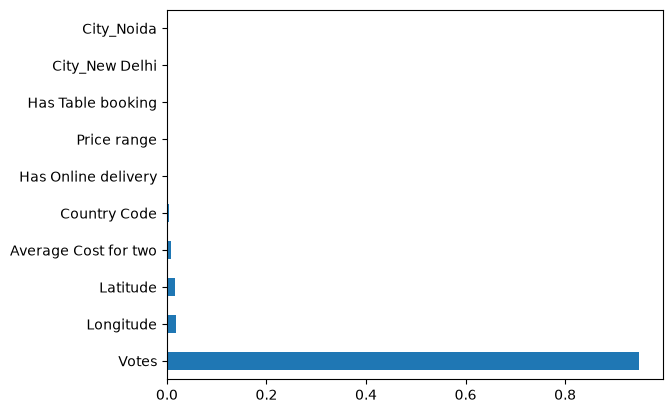

In [22]:
#feature importance for the best model (Random Forest)
#retrieve the best model based on R2 score
rf_model = models['Random Forest']
#extract feature importances
feature_importances =pd.Series(rf_model.feature_importances_, index=x_encoded.columns)
#sort the feature importances in descending order
top_features = feature_importances.sort_values(ascending=False)
#plot the top 10 features
top_features.head(10).plot(kind='barh')

In [ ]:
# summary
# - votes :direct correlation with aggregate rating, more votes means more people have rated the restaurant and hence the rating is more reliable
# - longitude and latitude : restaurants in certain locations may have higher ratings due to factors such as accessibility, ambiance, and local preferences
# - country code : different countries may have different food cultures and preferences, which can affect the ratings of restaurants in those countries
# - price range : restaurants with higher price ranges may be perceived as more upscale and therefore receive higher ratings